# 1.2. Exploratory Data Analysis
The purpose of this lab is to conduct exploratory data analysis.

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

In [2]:
path = Path.cwd().parent / 'data' / 'processed' / 'api-launch-data-table-class.csv'
df = pd.read_csv(path)

In [3]:
df.head(5)

,launch_designator,booster_version,orbit,launch_site,flights,reused,landing_pad,block,serial,longitude,latitude,reused_count,outcome,OrbPay,launch_date,gridfins,legs,class
0,2020-084,Falcon 9,Low Earth Orbit,Launch Complex 39A,23,False,JRTI,Block 5,B1061,-80.604282,28.608227,0,True ASDS,13.0,2020-11-16,True,True,1
1,2020-078,Falcon 9,Medium Earth Orbit,Space Launch Complex 40,23,False,OCISLY,Block 5,B1062,-80.577357,28.561941,0,True ASDS,4.4,2020-11-05,True,True,1
2,2020-074,Falcon 9,Low Earth Orbit,Space Launch Complex 40,20,True,JRTI,Block 5,B1060,-80.577357,28.561941,2,True ASDS,16.0,2020-10-24,True,True,1
3,2020-073,Falcon 9,Low Earth Orbit,Launch Complex 39A,14,True,OCISLY,Block 5,B1051,-80.604282,28.608227,5,True ASDS,16.0,2020-10-18,True,True,1
4,2020-070,Falcon 9,Low Earth Orbit,Launch Complex 39A,19,True,OCISLY,Block 5,B1058,-80.604282,28.608227,2,True ASDS,16.0,2020-10-06,True,True,1


Plot the payload mass over time and label by launch outcome.

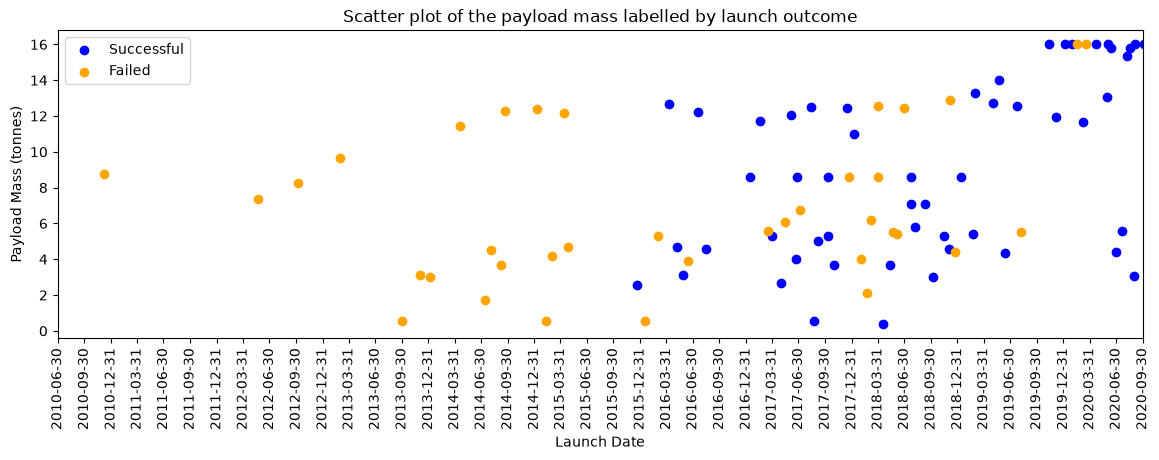

In [5]:
df1 = df[['OrbPay', 'class']]
df1.index = pd.to_datetime(df['launch_date'])

fig, ax = plt.subplots(figsize=(14,4))
mask = df1['class'] == 1
ax.scatter(df1[mask].index, df1[mask]['OrbPay'], color='blue', label='Successful')
ax.scatter(df1[~mask].index, df1[~mask]['OrbPay'], color='orange', label='Failed')

xticks = pd.date_range(start = df1.index.min(),
                      end = df1.index.max(),
                      freq = 'QE')
ax.set_xticks(xticks, xticks.strftime('%Y-%m-%d'), rotation=90)
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Payload Mass (tonnes)')
ax.set_title('Scatter plot of the payload mass labelled by launch outcome')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'payload_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight:** From the plot of the payload and launch outcome over time, it can be seen that most of the latest flights were successful and were able to carry higher payloads.

Plot the launch site used over time and label with launch outcome.

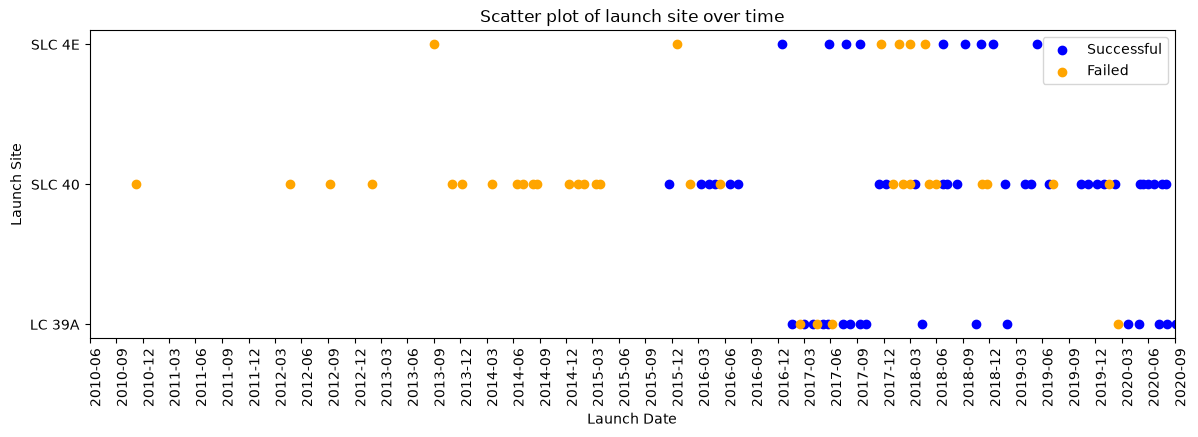

In [6]:
fig, ax = plt.subplots(figsize=(14,4))
mask = df['class'] == 1
xaxis = pd.to_datetime(df['launch_date'])

# Successful launches
ax.scatter(
    xaxis[mask],
    df[mask]['launch_site'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    xaxis[~mask],
    df[~mask]['launch_site'],
    color= 'orange',
    label = 'Failed'
)

ax.set_xticks(xticks, xticks.strftime('%Y-%m'), rotation=90, ha='left')
ax.set_yticks(list(df['launch_site'].unique())[::-1], ['SLC 4E', 'SLC 40', 'LC 39A'])
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Launch Site')
ax.set_title('Scatter plot of launch site over time')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'launchsite_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** SpaceX has done most of its launches in Space Launch Complex 40. At the beginning of their Falcon 9 projects, most of the launches in SLC 40 have failed to land but most of the recent launches in the site were successful. On the other hand, there were periods where all launches were conducted in either SLC 4E and LC 39A; particularly in late 2016 up to late 2017. Most of the launches by then were successful, but, overall, the LC 39A proved to be the best in terms of proportion of successful launches.

Visualize the relationship between payload and launch site

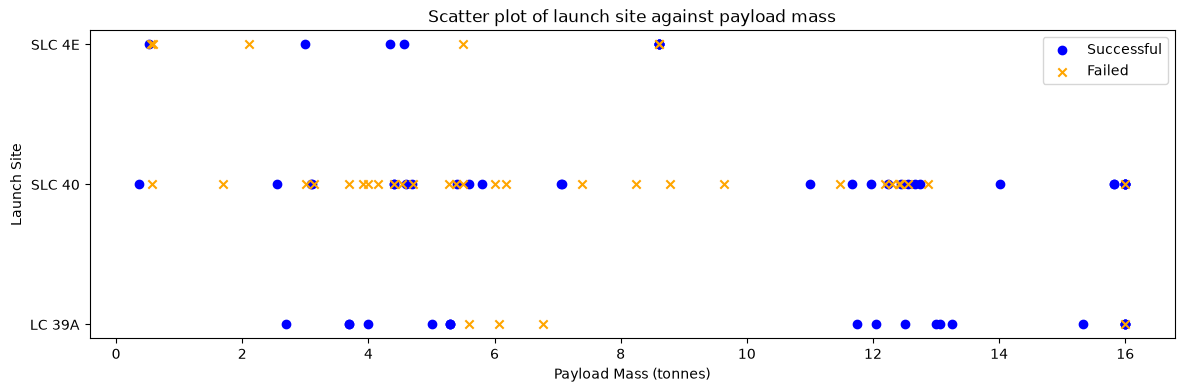

In [7]:
fig, ax = plt.subplots(figsize=(14,4))

# Successful launches
ax.scatter(
    df[mask]['OrbPay'],
    df[mask]['launch_site'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    df[~mask]['OrbPay'],
    df[~mask]['launch_site'],
    color = 'orange',
    label = 'Failed',
    marker = 'x'
)

ax.set_yticks(list(df['launch_site'].unique())[::-1], ['SLC 4E', 'SLC 40', 'LC 39A'])
ax.set_xlabel('Payload Mass (tonnes)')
ax.set_ylabel('Launch Site')
ax.set_title('Scatter plot of launch site against payload mass')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'launchsite_vs_payload'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** At low payloads, launches in Space launch complex failed to land, but higher payloads resulted in successful missions. Furthermore, launches conducted in SLC 4E only reach up to 10 tonnes of payload. On the other hand, launches in LC 39A have landed successfully at a wide range of payloads with only 4 failed landings, 3 of which have similar payloads.

Visualize the relationship between orbit type and success rate

In [8]:
success_count = df.groupby('orbit')['class'].sum()
total_missions = df.groupby('orbit')['class'].count()
success_count

orbit
Geostationary Transfer Orbit    13
Heliocentric L1                  0
High Earth Orbit                 1
Low Earth Orbit                 34
Lunar Orbit                      1
Medium Earth Orbit               2
Polar Orbit                      1
Sun-Synchronous Orbit            5
Name: class, dtype: int64

In [9]:
total_missions

orbit
Geostationary Transfer Orbit    28
Heliocentric L1                  1
High Earth Orbit                 1
Low Earth Orbit                 54
Lunar Orbit                      1
Medium Earth Orbit               3
Polar Orbit                      1
Sun-Synchronous Orbit            6
Name: class, dtype: int64

In [10]:
success_rate = 100*success_count/total_missions #in percent (%)
success_rate = success_rate.sort_values(ascending=True)
success_rate

orbit
Heliocentric L1                   0.000000
Geostationary Transfer Orbit     46.428571
Low Earth Orbit                  62.962963
Medium Earth Orbit               66.666667
Sun-Synchronous Orbit            83.333333
High Earth Orbit                100.000000
Lunar Orbit                     100.000000
Polar Orbit                     100.000000
Name: class, dtype: float64

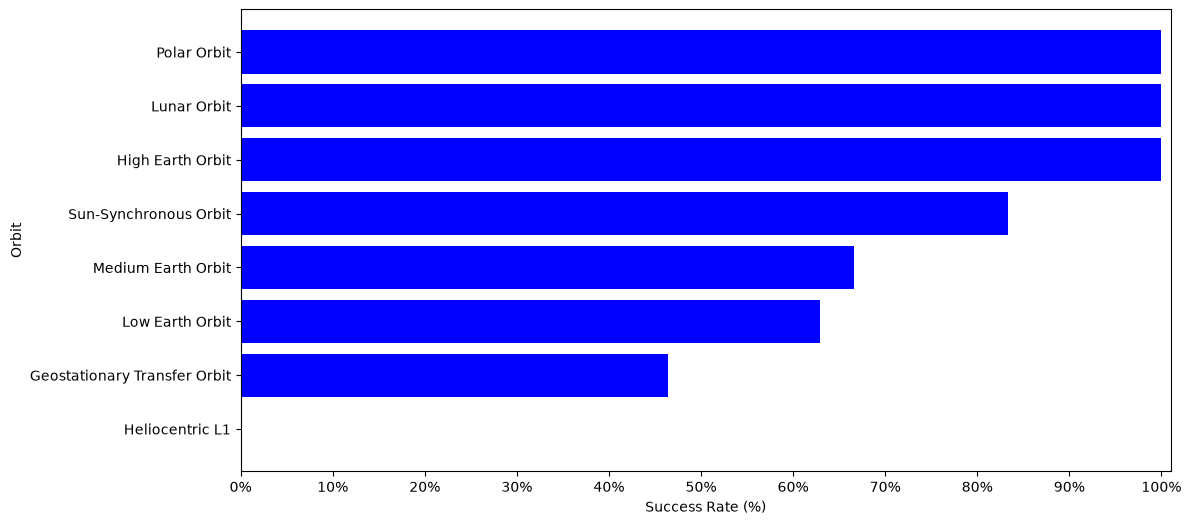

In [11]:
fig = plt.figure(figsize=(12,6))
plt.barh(success_rate.index, success_rate.values, color='blue')
plt.xlabel('Success Rate (%)')
plt.xlim(success_rate.values.min(), success_rate.values.max()+1)
plt.xticks(np.arange(0,110,10), list(map(lambda x: '{:.0f}%'.format(x), np.arange(0,110,10))))
plt.ylabel('Orbit')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'success_rate_orbits.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.show()

Visualize the trend of orbit type over time colored by class.

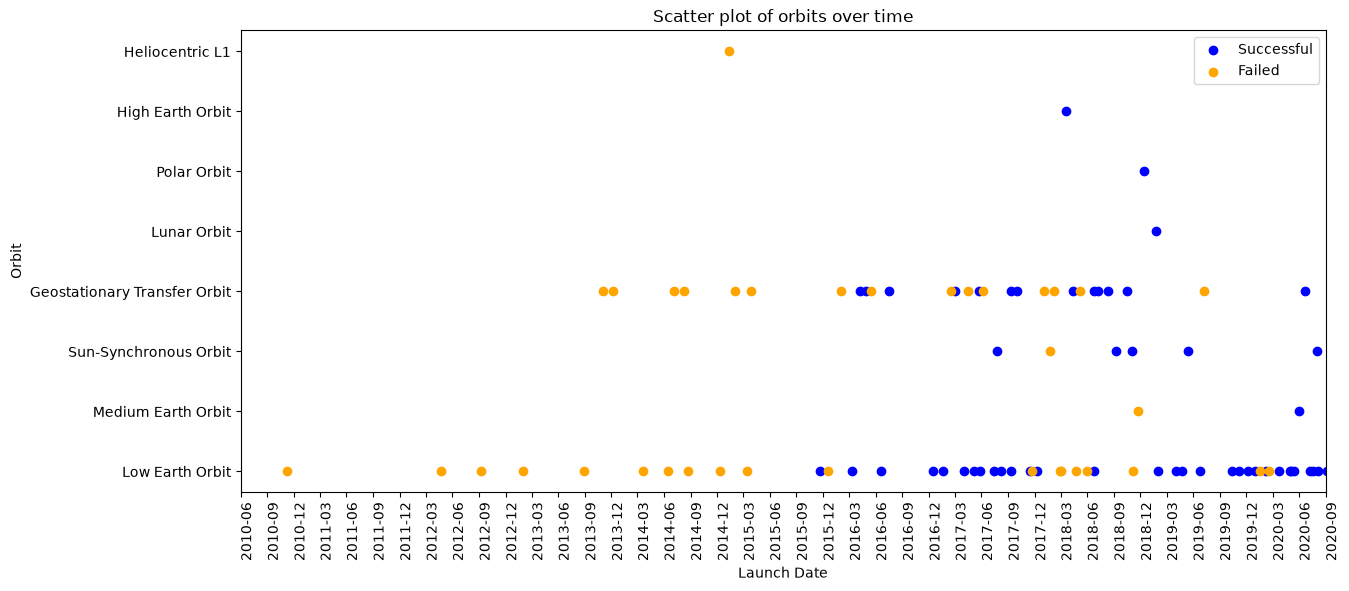

In [12]:
fig, ax = plt.subplots(figsize=(14,6))
df2 = df.dropna(axis=0)
mask = df2['class'] == 1
xaxis = pd.to_datetime(df2['launch_date'])

# Successful launches
ax.scatter(
    xaxis[mask],
    df2[mask]['orbit'],
    color = 'blue',
    label = 'Successful'
)

# Failed launches
ax.scatter(
    xaxis[~mask],
    df2[~mask]['orbit'],
    color= 'orange',
    label = 'Failed'
)

ax.set_xticks(xticks, xticks.strftime('%Y-%m'), rotation=90, ha='left')
ax.set_yticks(list(df2['orbit'].unique())[::-1])
ax.set_xlim(xticks.min(), xticks.max())
ax.set_xlabel('Launch Date')
ax.set_ylabel('Orbit')
ax.set_title('Scatter plot of orbits over time')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'orbits_time_series.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** Most successful missions are clustered at later dates for any orbit. There was one mission around the Heliocentric L1 orbit, and that one mission failed; but it was conducted at an earlier date and was not attempted later. Many of the launches were missions around the Low Earth Orbit and were mostly successful at later dates. Furthermore, it appears that, for missions around the Geostationary Transfer Orbit, launch date and mission outcome have the weakest relationship.

Visualize the relationship between payload and orbit type.

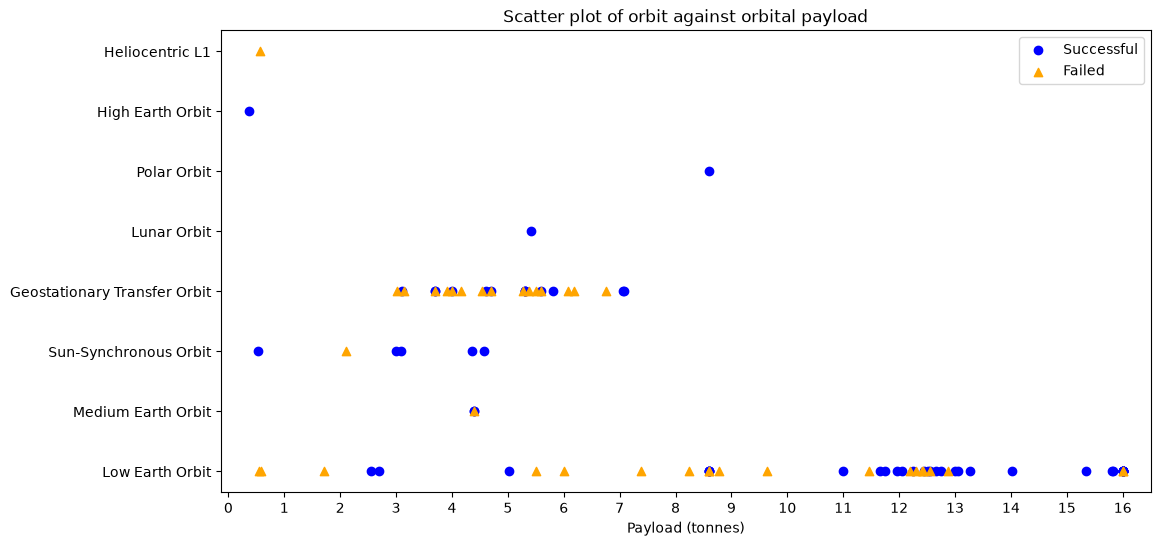

In [13]:
fig,ax = plt.subplots(figsize=(12,6))
ax.scatter(df2[mask]['OrbPay'], df2[mask]['orbit'] , color='blue', marker='o', label='Successful')
ax.scatter(df2[~mask]['OrbPay'], df2[~mask]['orbit'], color='orange', marker='^', label='Failed')
ax.set_xlim(df2['OrbPay'].min()-0.5, df2['OrbPay'].max()+0.5)
ax.set_xticks(np.arange(0,17))
ax.set_xlabel('Payload (tonnes)')
ax.set_title('Scatter plot of orbit against orbital payload')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'orbit_vs_payload.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.legend()
plt.show()

**Insight.** For missions around the Low Earth Orbit and the Sun-Synchronous Orbit, a higher payload roughly results in a successful flight. Similar to orbit against launch dates, there is no clear relationship between outcome and payload mass for missions around the geostationary orbit. It is even more difficult to assess the relationship for the rest of the orbits.

In [15]:
df3 = df.set_index(pd.to_datetime(df['launch_date']))
success_count_year = df3.resample('YE')['class'].mean().dropna(axis=0)

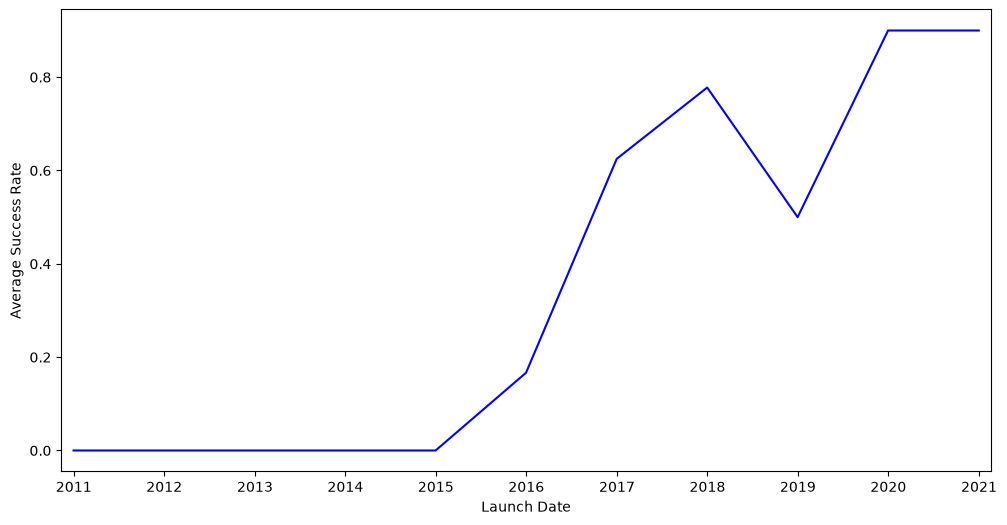

In [17]:
from datetime import timedelta

fig = plt.figure(figsize=(12,6))
plt.plot(success_count_year.index, success_count_year.values, color = 'blue')
plt.xlim(success_count_year.index.min() - timedelta(days=50),success_count_year.index.max() + timedelta(days=50))
plt.xlabel('Launch Date')
plt.ylabel('Average Success Rate')

# Save figure
path_to_fig = Path.cwd().parent / 'reports' / 'mean_success_rate.png'
fig.savefig(path_to_fig, bbox_inches='tight')

plt.show()

# Additional - Rev 1

In [380]:
from spacey_falcon_9_project.config import processed_dir, training_set

df = pd.read_csv(processed_dir / training_set, na_filter=False)
df.head()

,launch_designator,booster_version,orbit,mission_type,launch_site,landing_success,landing_type,flights,reused,landing_pad,...,serial,longitude,latitude,reused_count,payload_mass,launch_date,class,nearest_highway,nearest_railway,nearest_coastline
0,2025-037,Falcon 9,Low Earth Orbit,Communications,Space Launch Complex 4E,True,ASDS,22,True,OCISLY,...,B1082,-120.611000,34.632000,10,15.500,2025-02-23,1,30.520335,1.252787,1.468531
1,2018-076,Falcon 9,Sun-Synchronous Orbit,Communications,Space Launch Complex 4E,True,RTLS,5,True,LZ-4,...,B1048,-120.611000,34.632000,1,3.000,2018-10-08,1,30.520335,1.252787,1.468531
2,2022-097,Falcon 9,Low Earth Orbit,Communications,Launch Complex 39A,True,ASDS,21,True,ASOG,...,B1073,-80.604282,28.608227,2,15.644,2022-08-10,1,22.499530,19.984845,0.544885
3,2022-094,Falcon 9,Elliptical Orbit,Lunar Exploration,Space Launch Complex 40,True,ASDS,8,True,JRTI,...,B1052,-80.577357,28.561941,5,0.678,2022-08-04,1,17.694811,21.169013,0.930777
4,2026-001,Falcon 9,Sun-Synchronous Orbit,Earth Science,Space Launch Complex 4E,True,RTLS,25,True,LZ-4,...,B1081,-120.611000,34.632000,20,2.200,2026-01-03,1,30.520335,1.252787,1.468531


In [381]:
df[df['landing_success'] == 'False'].head()

,launch_designator,booster_version,orbit,mission_type,launch_site,landing_success,landing_type,flights,reused,landing_pad,...,serial,longitude,latitude,reused_count,payload_mass,launch_date,class,nearest_highway,nearest_railway,nearest_coastline
86,2016-013,Falcon 9,Geostationary Transfer Orbit,Communications,Space Launch Complex 40,False,ASDS,1,False,OCISLY,...,B1020,-80.577357,28.561941,0,5.271,2016-03-04,0,17.694811,21.169013,0.930777
125,2015-001,Falcon 9,Low Earth Orbit,Resupply,Space Launch Complex 40,False,ASDS,1,False,JRTI,...,B1012,-80.577357,28.561941,0,12.410,2015-01-10,0,17.694811,21.169013,0.930777
203,2010-066,Falcon 9,Low Earth Orbit,Test Flight,Space Launch Complex 40,False,PCL,1,False,ATL,...,B0004,-80.577357,28.561941,0,8.774,2010-12-08,0,17.694811,21.169013,0.930777
220,2016-002,Falcon 9,Low Earth Orbit,Earth Science,Space Launch Complex 4E,False,ASDS,1,False,JRTI,...,B1017,-120.611000,34.632000,0,0.553,2016-01-17,0,30.520335,1.252787,1.468531
244,2021-012,Falcon 9,Low Earth Orbit,Communications,Space Launch Complex 40,False,ASDS,6,True,OCISLY,...,B1059,-80.577357,28.561941,5,16.000,2021-02-16,0,17.694811,21.169013,0.930777


In [382]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   launch_designator  441 non-null    str    
 1   booster_version    441 non-null    str    
 2   orbit              441 non-null    str    
 3   mission_type       441 non-null    str    
 4   launch_site        441 non-null    str    
 5   landing_success    441 non-null    str    
 6   landing_type       441 non-null    str    
 7   flights            441 non-null    int64  
 8   reused             441 non-null    bool   
 9   landing_pad        441 non-null    str    
 10  block              441 non-null    str    
 11  serial             441 non-null    str    
 12  longitude          441 non-null    float64
 13  latitude           441 non-null    float64
 14  reused_count       441 non-null    int64  
 15  payload_mass       441 non-null    float64
 16  launch_date        441 non-null    st

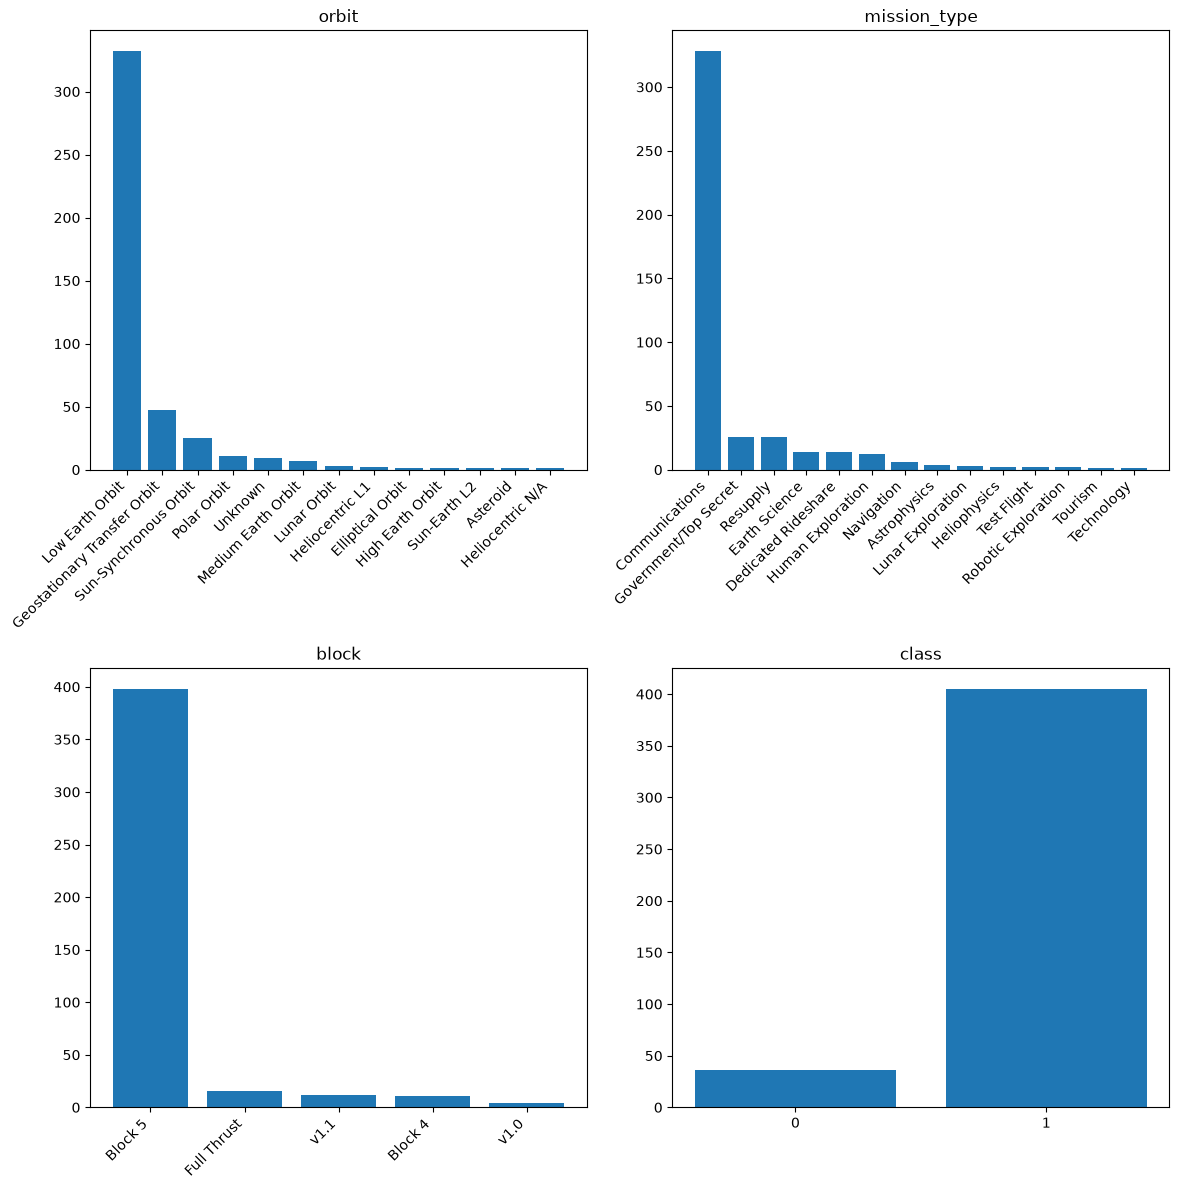

In [383]:
def catplot(series: str, ax = None) -> None:
    if not ax:
        ax = plt.gca()
    
    cat = df[series].value_counts()
    ax.bar(cat.index, cat.values)
    ax.set_title(series)
    ax.set_xticks(cat.index)
    
    if cat.index.dtype=='str':
        ax.tick_params(axis='x', rotation=45, rotation_mode='xtick')
    
cats = ['orbit', 'mission_type', 'block', 'class']

fig, axs = plt.subplots(2,2,figsize=(12,12))

for cat,ax in zip(cats,axs.flat):
    catplot(cat, ax)

fig.tight_layout()
plt.show()

**Findings.**
- Mission types with less than 10 instances will be collasped into "others" category.
- Class is heavily imbalanced. 

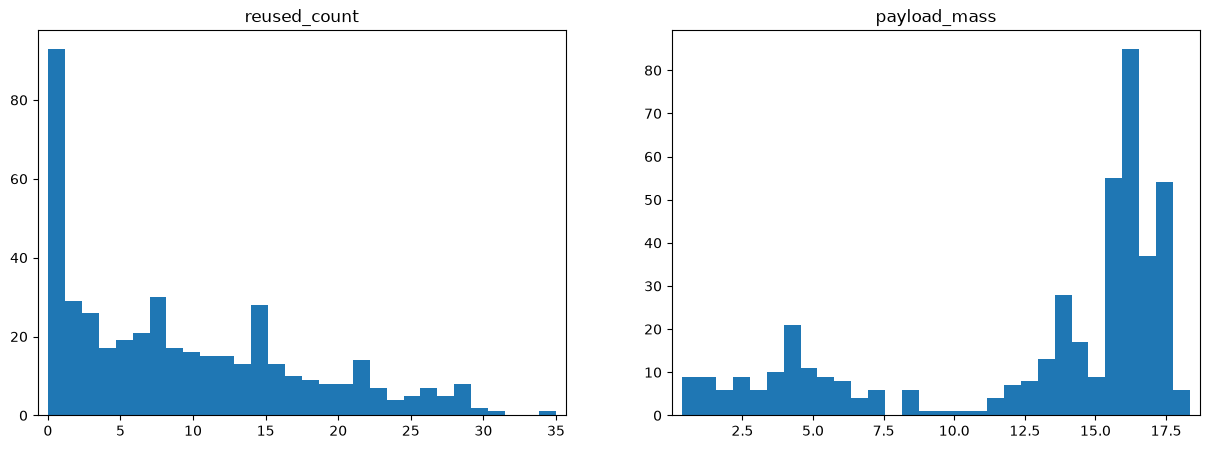

In [384]:
nums = ['reused_count', 'payload_mass']

def numplot(series: str, bins: int = 10, ax = None) -> None:
    if not ax:
        ax = plt.gca()
    
    ax.hist(df[series], bins=bins)
    ax.set_title(series)

    offset = 0.02*(df[series].max() - df[series].min())
    ax.set_xlim(df[series].min()-offset, df[series].max()+offset)

fig,axs = plt.subplots(1,2,figsize=(15,5))

for num,ax in zip(nums[:2],axs.flat):
    numplot(num,30,ax=ax)

plt.show()

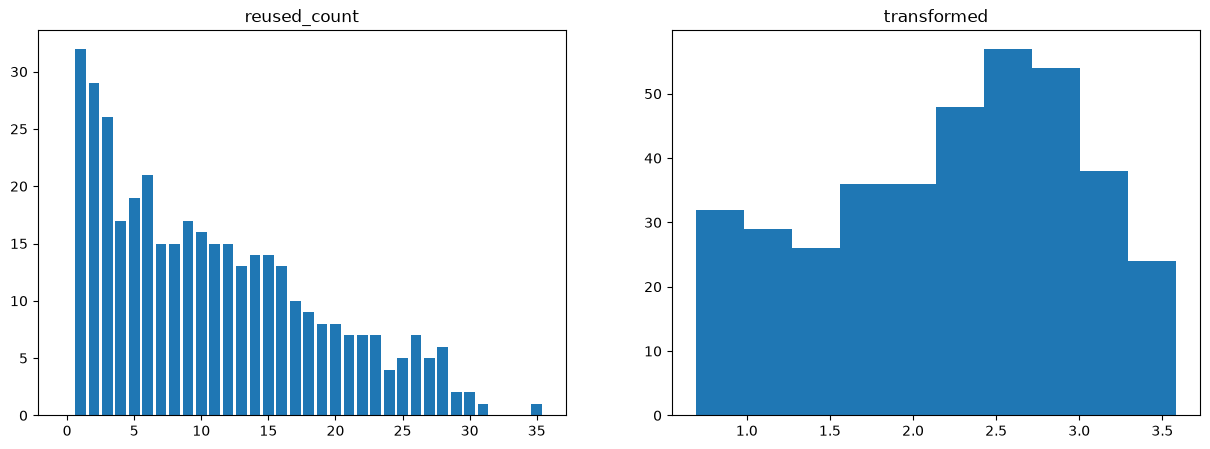

In [385]:
mask = df['reused_count'] >= 1
reused_count = (df['reused_count'])[mask].to_numpy()
transform = np.log1p(reused_count)

fig, axs = plt.subplots(1,2,figsize=(15,5))

bins = np.bincount(reused_count)
axs[0].bar(range(len(bins)), bins)
axs[0].set_title('reused_count')
axs[1].hist(transform)
axs[1].set_title('transformed')

plt.show()

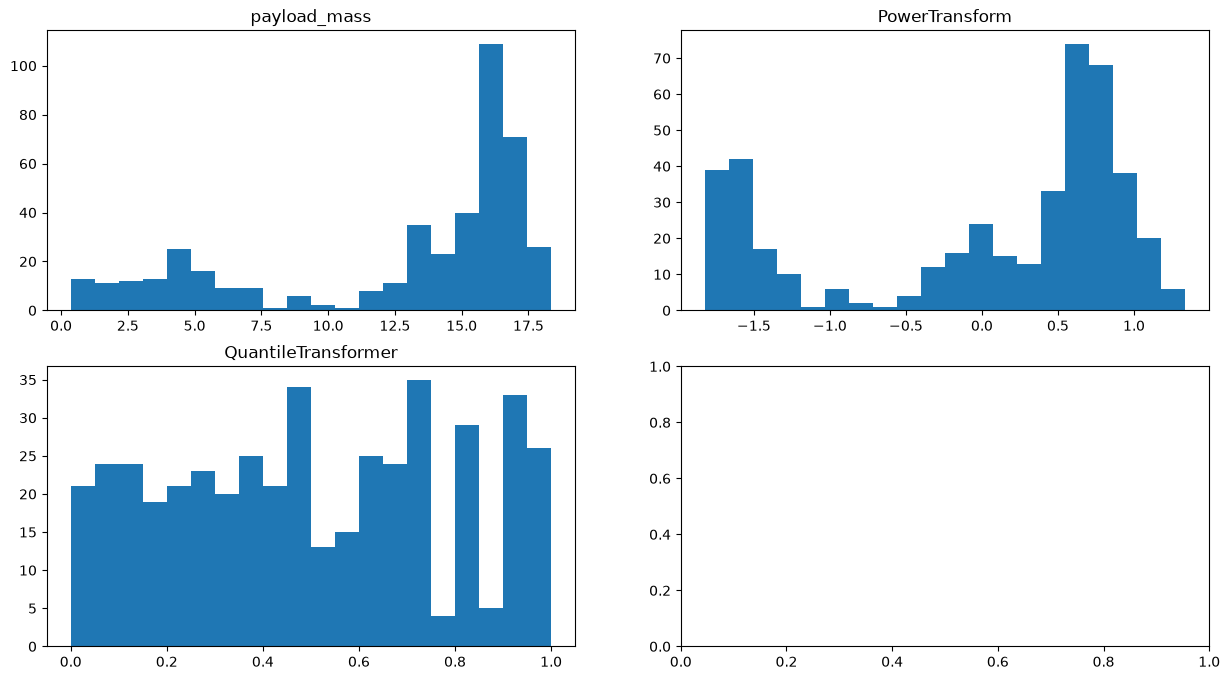

In [386]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer

payload_mass = df['payload_mass'].to_numpy()
transform1 = QuantileTransformer(n_quantiles=len(payload_mass)).fit_transform(payload_mass.reshape(-1,1)).reshape(payload_mass.shape)
transform2 = PowerTransformer().fit_transform(payload_mass.reshape(-1,1)).reshape(payload_mass.shape)

fig, axs = plt.subplots(2,2,figsize=(15,8))
bins = [20,20,20]
names = {'payload_mass': payload_mass, 'PowerTransform': transform2, 'QuantileTransformer': transform1}

for name, bin_, ax in zip(names.items(), bins, axs.flat):
    ax.hist(name[1], bins=bin_)
    ax.set_title(name[0])

**Findings.** For payload mass and reused count, a transformation prior to scaling may be necessary.

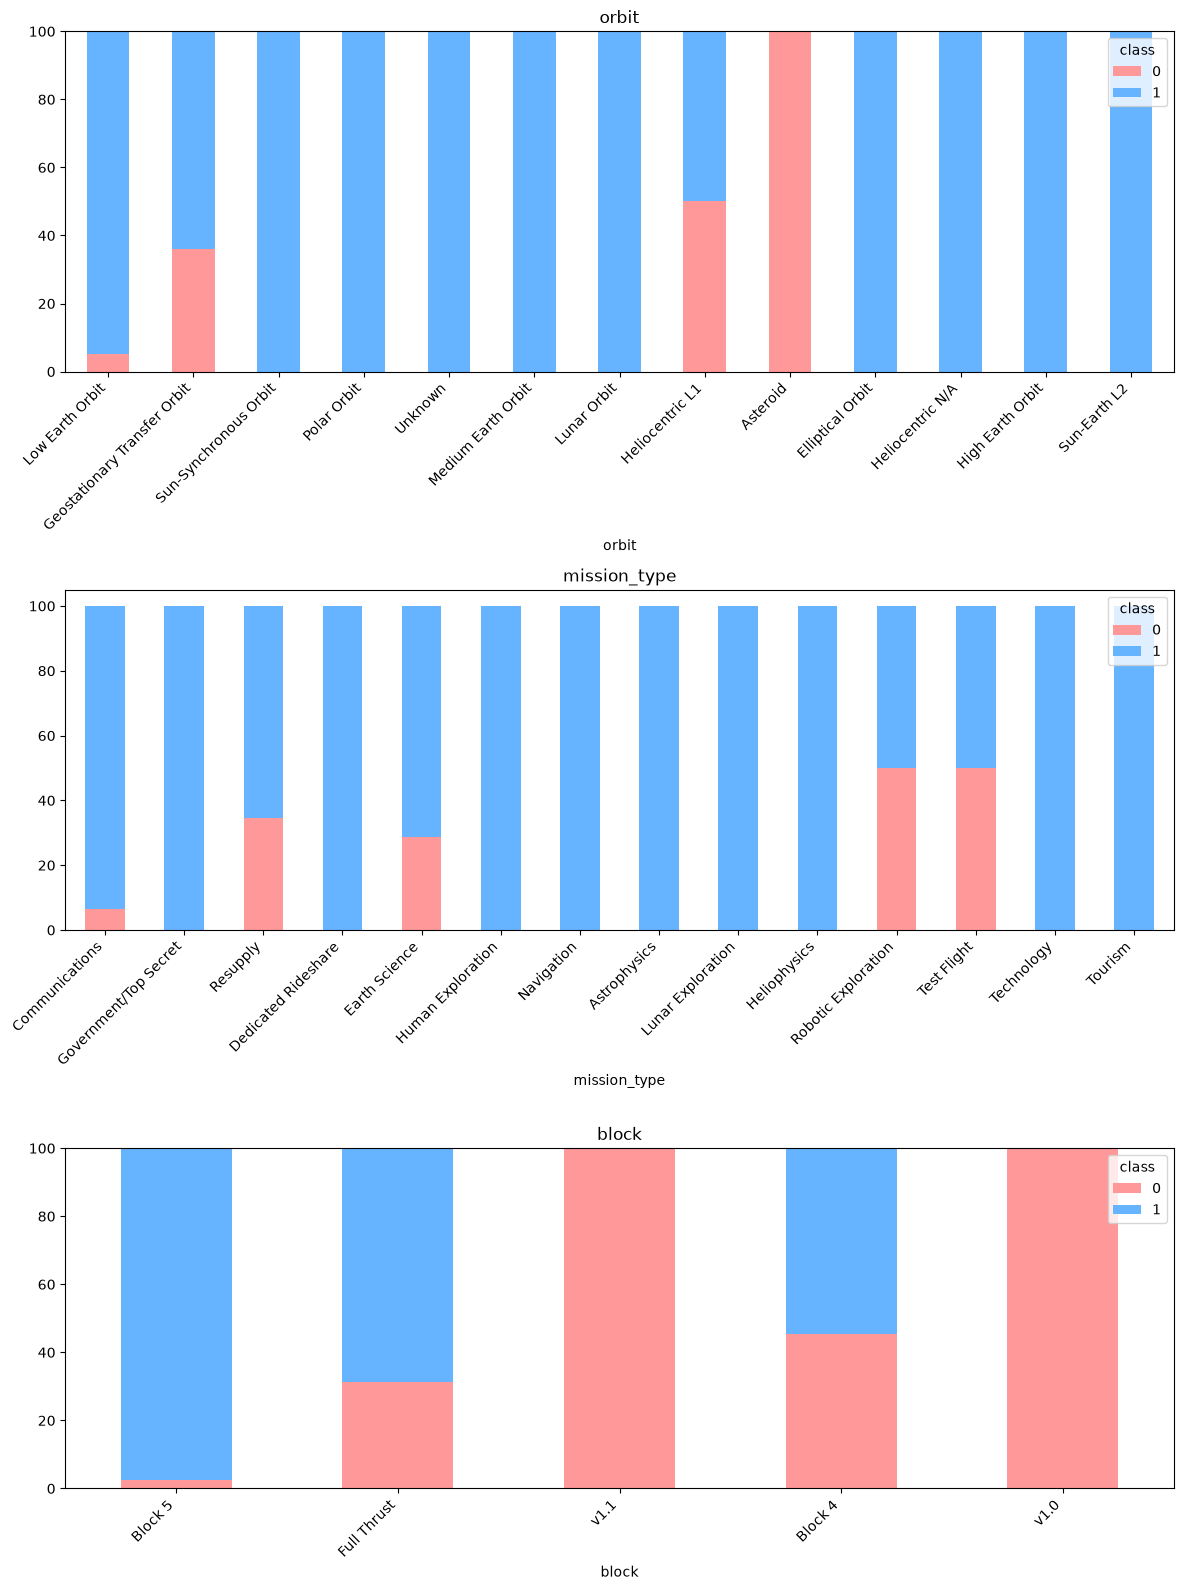

In [387]:
def class_corr(attr: str, ax = None) -> None:
    if not ax:
        ax = plt.gca()

    orbit_class_pct = pd.crosstab(df[attr], df['class'], normalize="index") * 100
    orbit_class_pct = orbit_class_pct.sort_index(ascending=False, key=lambda x: df[attr].value_counts()[x])
    orbit_class_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    ax.tick_params(axis='x', rotation=45, rotation_mode='xtick')

fig,axs = plt.subplots(3,1, figsize=(12,16))

for cat, ax in zip(cats[:-1],axs.flat):
    class_corr(cat, ax)
    ax.set_title(cat)

fig.tight_layout()
plt.show()

For `orbit`:
- Orbits with less than 10 instances will be grouped to `Others`

For `mission_type`:
- Mission types with less than 10 instances will be grouped to `Others`
- It may also be good to consider domain grouping:
  - **Commercial** - Communications, Dedicated Rideshare, Tourism
  - **Science & Defense** - Government/Top Secret, Earth Science, Astrophysics, Heliophysics, Lunar Exploration, Robotic Exploration, Navigation, Technology.
  - **ISS / Spaceflight** - Resupply, Human Exploration, Test Flight.

For `block`:
- Legacy versions FT, v1.1, B4, and v1.0 will be grouped to 'Legacy'.

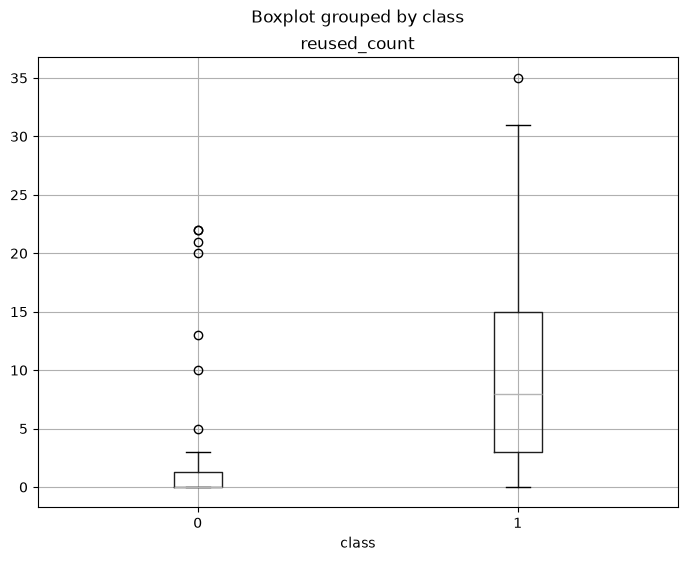

In [388]:
df.boxplot(column='reused_count', by='class', figsize=(8,6))
plt.show()

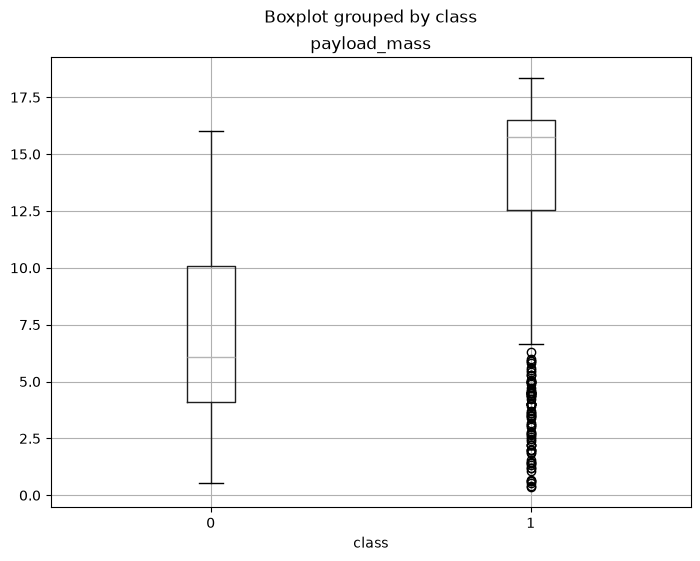

In [389]:
df.boxplot(column='payload_mass', by='class', figsize=(8,6))
plt.show()

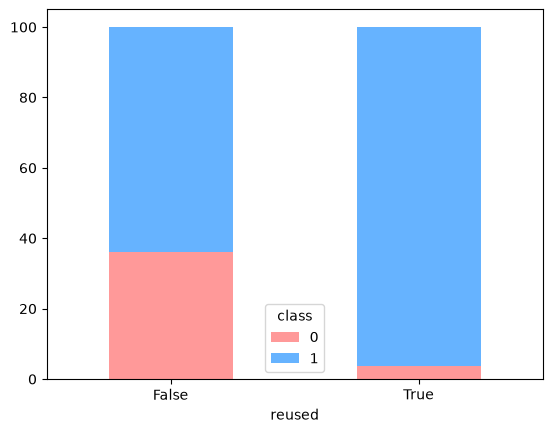

In [390]:
ax = plt.gca()
reused_class_pct = pd.crosstab(df['reused'], df['class'], normalize='index')*100
reused_class_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
ax.tick_params(rotation=0)

**Conclusion univariate analysis**
 - **Selected features:** `payload_mass`, `reused_count`, `orbit`, `mission_type`, `block`, `nearest_highway`, `nearest_coastline`, `nearest_railway`
 - **Transformations to be applied:**
   - `payload_mass` - due to its bimodal distribution, create two features for the two modes representing the similarity of the data with the two modes.
   - `reused_count` - apply a `log1p` transform
   - `orbit` - Categories with less than 10 instances will be grouped to others
   - `block` - Inactive versions will be grouped to `Legacy`
   - `mission_type` - mission types with less than 10 instances will be grouped to `Others`. Also, consider domain grouping:
     - Commercial - Communications, Dedicated Rideshare, Tourism
     - Science & Defense - Government/Top Secret, Earth Science, Astrophysics, Heliophysics, Lunar Exploration, Robotic Exploration, Navigation, Technology.
     - ISS / Spaceflight - Resupply, Human Exploration, Test Flight.

In [391]:
df[['payload_mass', 'reused_count']].corr()

,payload_mass,reused_count
payload_mass,1.000000,0.324973
reused_count,0.324973,1.000000


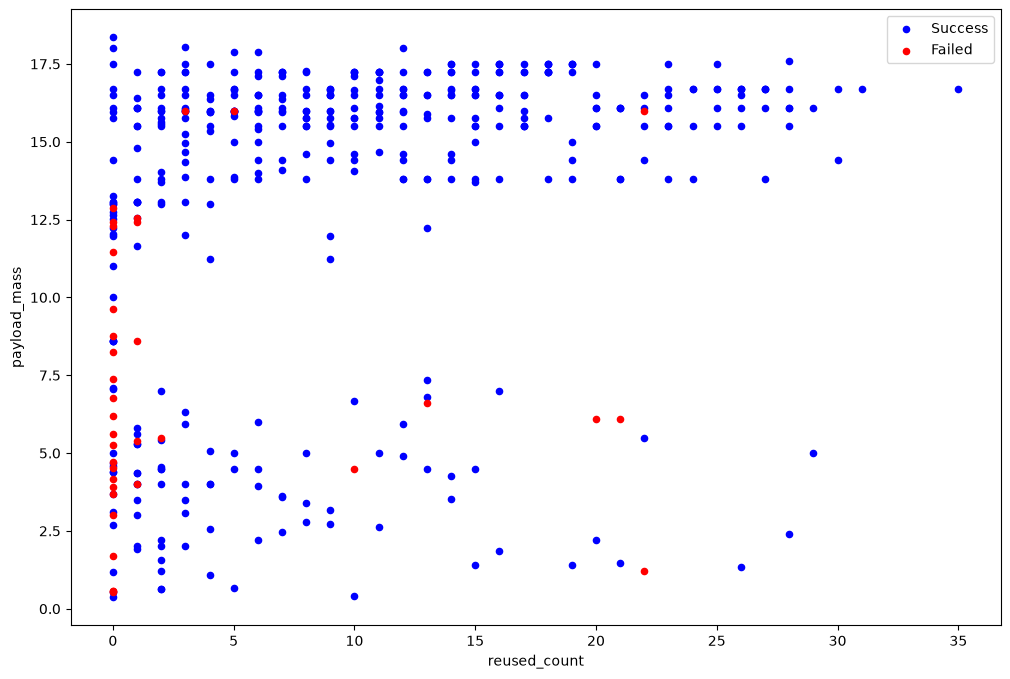

In [392]:
fig,ax = plt.subplots(figsize=(12,8))
mask = df['class']==1
df[mask].plot(kind='scatter', x='reused_count', y='payload_mass', c='blue', ax=ax, label='Success')
df[~mask].plot(kind='scatter', x='reused_count', y='payload_mass', c='red', ax=ax, label='Failed')

plt.legend()
plt.show()

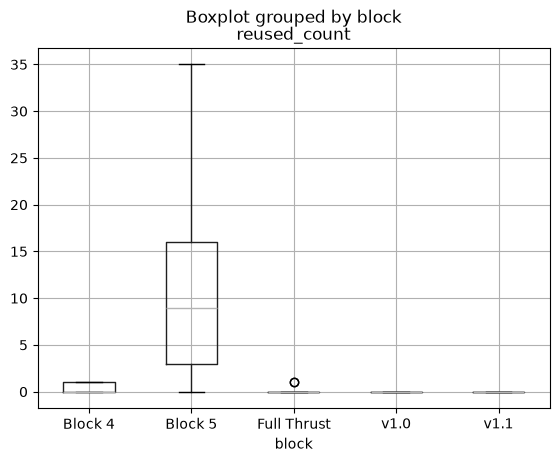

In [393]:
df.boxplot(column='reused_count', by='block')
plt.show()